In [311]:
import numpy as np
import matplotlib.pyplot as plt

In [312]:
def calculate_b0_b1(x,y):
  n=np.size(x)
  mean_x,mean_y=np.mean(x), np.mean(y)
  ss_xx=np.sum((x-mean_x)*(x-mean_x))
  ss_xy=np.sum((y-mean_y)*(x-mean_x))

  b1=ss_xy/ss_xx
  b0=mean_y-b1*mean_x
  return b0,b1
  #print(f'b1:{b1}\nb0:{b0}')


def plot_regression(x,y,b):
  plt.scatter(x,y,color='r',marker='D')
  y_pred=b[0]+b[1] *x
  plt.xlabel('no.of sales')
  plt.ylabel('no.of weeks')
  plt.plot(x,y_pred, color='b')
  plt.show()

In [313]:
x=np.array([1,2,3,4,5])
y=np.array([2,4,5,4,5])
res=calculate_b0_b1(x,y)
res

(np.float64(2.2), np.float64(0.6))

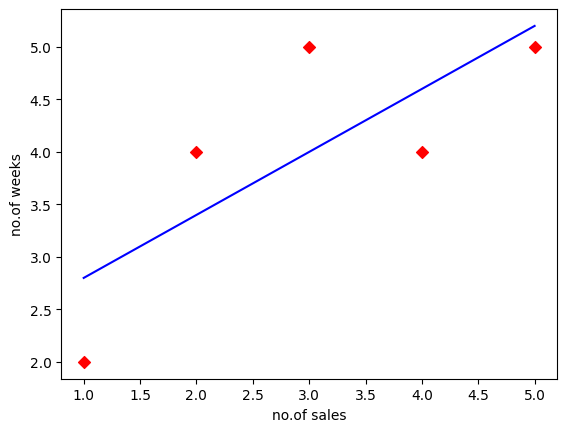

In [314]:
x=np.array([1,2,3,4,5])
y=np.array([2,4,5,4,5])
b=calculate_b0_b1(x,y)
plot_regression(x,y,b)

In [315]:
b

(np.float64(2.2), np.float64(0.6))

In [316]:
print("Estimated Coefficients: \nb0 = {} \nb1 = {}".format(b[0], b[1]))

Estimated Coefficients: 
b0 = 2.2 
b1 = 0.6


In [317]:
un_pack=(4,5,6)
un_pack[0]
un_pack[2]

6

#Linear Regression

In [318]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

In [319]:
data=pd.read_csv('/content/Student_Performance.csv')
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [320]:
df=data.copy()
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [321]:
df.shape

(10000, 6)

In [322]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [323]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [324]:
#null values

df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [325]:
#null values percentage

df.isnull().sum()/len(df)*100

,0
Hours Studied,0.0
Previous Scores,0.0
Extracurricular Activities,0.0
Sleep Hours,0.0
Sample Question Papers Practiced,0.0
Performance Index,0.0


In [326]:
df.dropna(inplace=True)  #drop null values

# Null Values--> removing outliers

In [327]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

<Axes: xlabel='Previous Scores'>

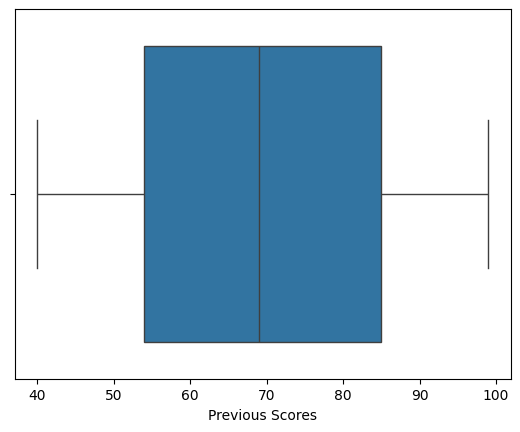

In [328]:
sns.boxplot(data=df, x='Previous Scores')

In [329]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

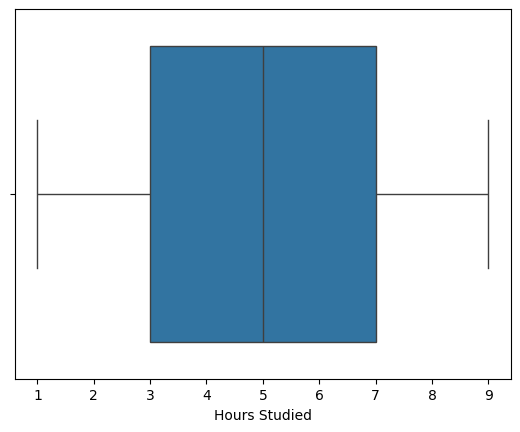

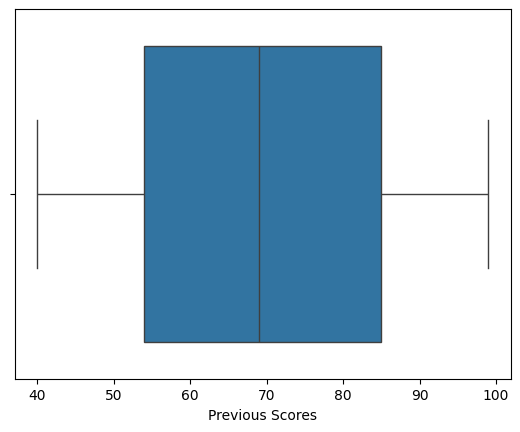

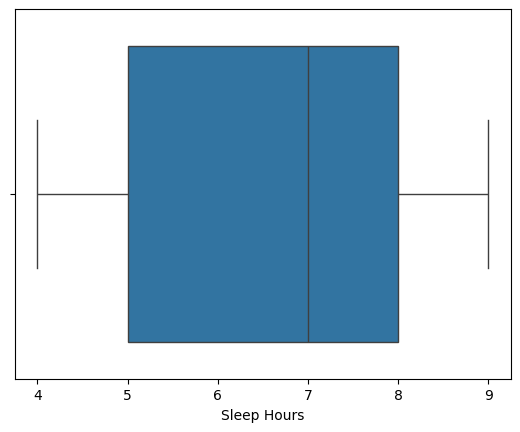

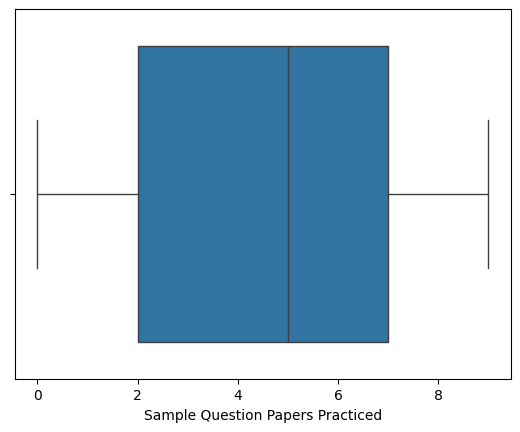

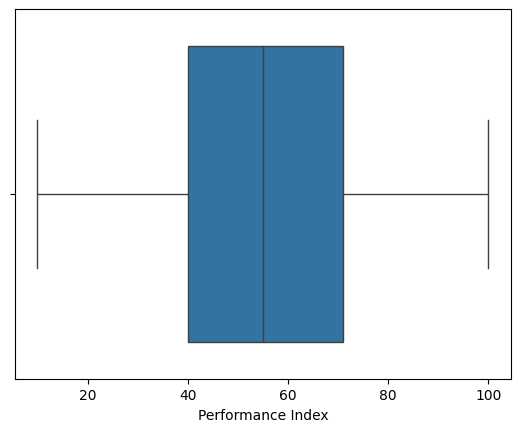

In [330]:
for i in df.columns:
  if df[i].dtype!='object':
    sns.boxplot(data=df, x=i)
    plt.show()

In [331]:
#integer columns

num_cols=df.select_dtypes(include=['int64']).columns
num_cols

Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',
       'Sample Question Papers Practiced'],
      dtype='object')

In [332]:
for col in num_cols:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)

  iqr=q3-q1

  ul=q3+1.5*iqr
  ll=q1-1.5*iqr

  dx=df[(df[col]<ul) & (df[col]>ll)]

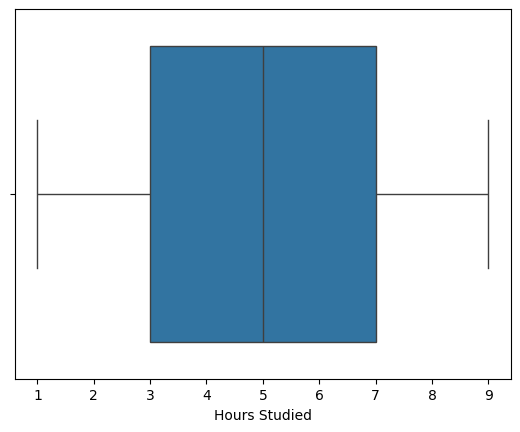

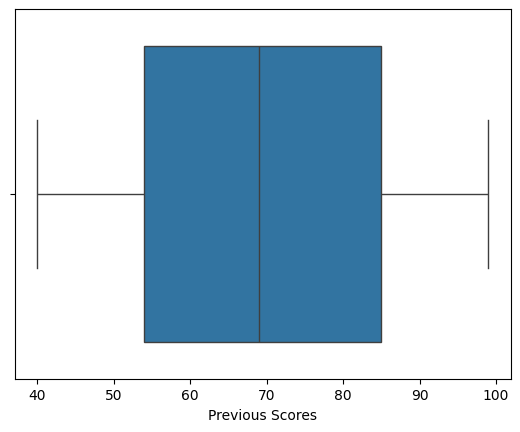

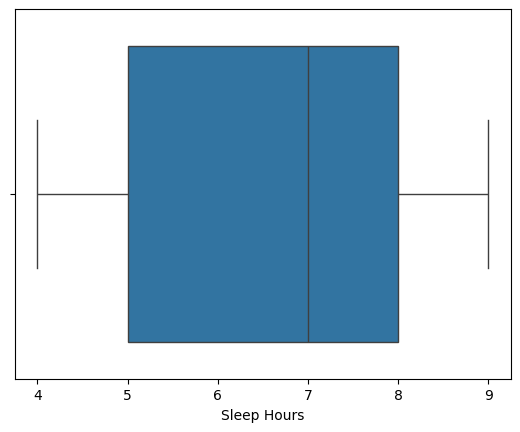

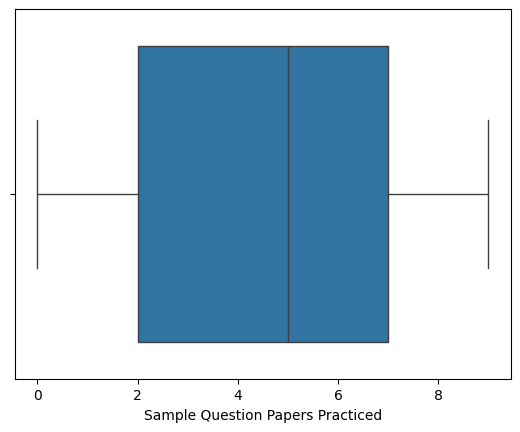

In [333]:
for col in num_cols:
  sns.boxplot(data=dx, x=col)
  plt.show()

In [334]:
dx.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [335]:
dx.shape

(10000, 6)

#correlation

In [336]:
dx[num_cols].corr()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
Hours Studied,1.000000,-0.012390,0.001245,0.017463
Previous Scores,-0.012390,1.000000,0.005944,0.007888
Sleep Hours,0.001245,0.005944,1.000000,0.003990
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000


<Axes: >

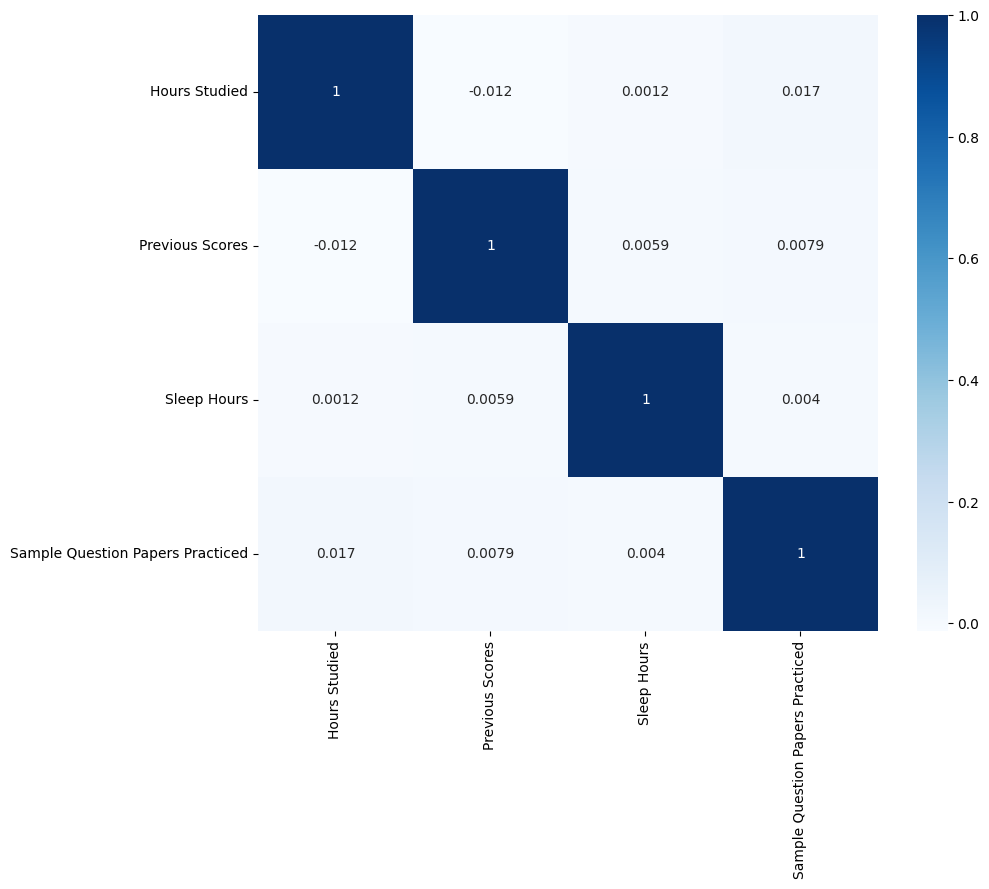

In [337]:
plt.figure(figsize=(10,8))
sns.heatmap(dx[num_cols].corr(), annot=True, cmap='Blues')

In [338]:
df['Extracurricular Activities']


,Extracurricular Activities
0,Yes
1,No
2,Yes
3,Yes
4,No
...,...
9995,Yes
9996,Yes
9997,Yes
9998,Yes


In [339]:
df['Extracurricular Activities'].unique()

array(['Yes', 'No'], dtype=object)

In [340]:
# Label Encoding
df['Extracurricular Activities']=df['Extracurricular Activities'].map({'Yes':0,'No':1})

In [341]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,0,9,1,91.0
1,4,82,1,4,2,65.0
2,8,51,0,7,2,45.0
3,5,52,0,5,2,36.0
4,7,75,1,8,5,66.0


#model building

In [342]:
x=df.drop('Performance Index', axis=1)
y=df['Performance Index']

In [343]:
x.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,0,9,1
1,4,82,1,4,2
2,8,51,0,7,2
3,5,52,0,5,2
4,7,75,1,8,5


In [344]:
y

,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0
...,...
9995,23.0
9996,58.0
9997,74.0
9998,95.0


In [345]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.25, random_state=100)

In [346]:
x_train.shape

(7500, 5)

In [347]:
x_test.shape

(2500, 5)

In [348]:
y_train.shape

(7500,)

In [349]:
y_test.shape

(2500,)

In [350]:
from sklearn.linear_model import LinearRegression

In [351]:
lr=LinearRegression()

In [352]:
model=lr.fit(x_train,y_train)
#lr.fit(x_train,y_train)

In [353]:
model

LinearRegression()

In [354]:
pred=model.predict(x_test)
#pred=lr.predict(x_test)

In [355]:
x_test

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
8018,2,88,0,6,6
9225,5,64,0,4,3
3854,5,49,1,9,9
2029,8,98,0,5,9
3539,9,87,1,7,7
...,...,...,...,...,...
6547,9,51,1,6,1
9068,4,89,1,4,3
485,2,44,0,6,4
5284,5,60,1,6,9


In [356]:
pred

array([65.99778689, 48.51357669, 36.16391351, ..., 20.76245717,
       45.93680159, 36.95923186])

In [357]:
lr.predict([[2,	88,	0,	6,	6]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([65.99778689])

In [358]:
from sklearn.metrics import r2_score, root_mean_squared_error

In [359]:
R2_score=r2_score(y_test,pred)

In [360]:
R2_score

0.9884600014918554

In [362]:
RMSE = root_mean_squared_error(y_test,pred)
RMSE

2.0763975792939173